In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv(r'D:\class\data_science\ai4i+2020+predictive+maintenance+dataset\ai4i2020.csv')

In [ ]:
# data understanding

In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [ ]:
# initail eda

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
# no null values in the dataset, so no need to handle missing values

In [8]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
# no outliers in data as there is no major differenece between meadin and mean of each col

In [9]:
df.describe(include='object')
# categorical data statistical info 

,Product ID,Type
count,10000,10000
unique,10000,3
top,M24859,L
freq,1,6000


<Axes: ylabel='count'>

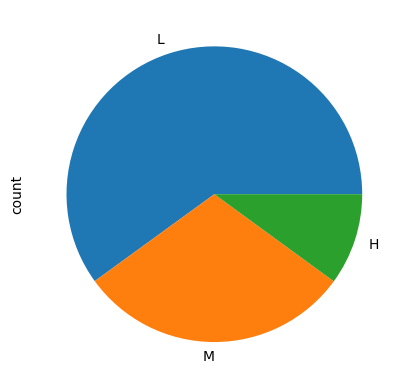

In [10]:
df.Type.value_counts().plot(kind="pie", color= ['Red', 'Green', 'blue'])

In [11]:
df.Type.value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [12]:
df.Type.unique()

array(['M', 'L', 'H'], dtype=object)

In [41]:
df.columns = df.columns.str.replace(" ", "_")

In [42]:
df.head()

,UDI,Product_ID,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


<Axes: >

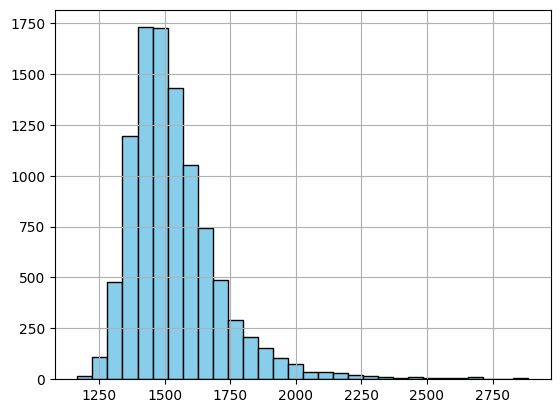

In [24]:
 
# distribution of data: discplot and histogram
df['Rotational_speed_[rpm]'].hist(bins=30, color= "skyblue", edgecolor="black")

In [ ]:
# right skewed distribution, no normal distribution

In [25]:
df.columns

Index(['UDI', 'Product_ID', 'Type', 'Air_temperature_[K]',
       'Process_temperature_[K]', 'Rotational_speed_[rpm]', 'Torque_[Nm]',
       'Tool_wear_[min]', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

<Axes: >

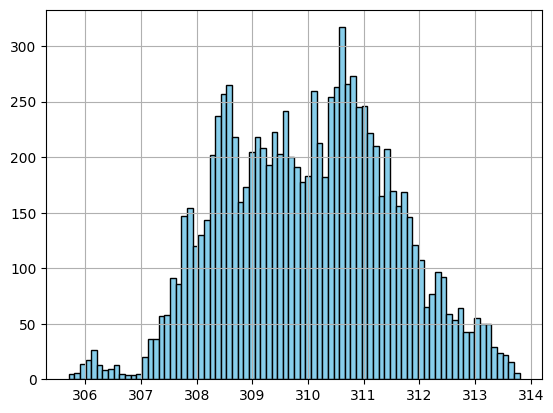

In [32]:
df['Process_temperature_[K]'].hist(bins=80, color= "skyblue", edgecolor="black")

In [ ]:
# outliers at left side in distribution

<Axes: >

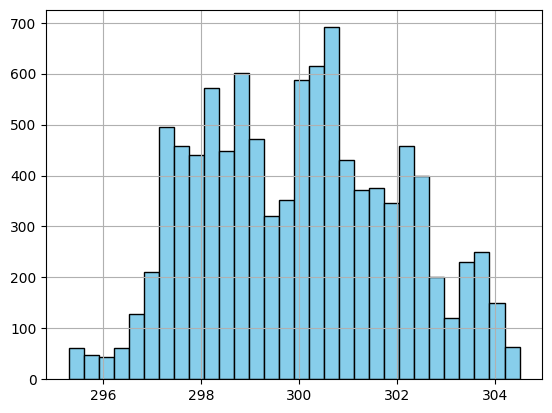

In [34]:
df['Air_temperature_[K]'].hist(bins=30, color= "skyblue", edgecolor="black")

<Axes: >

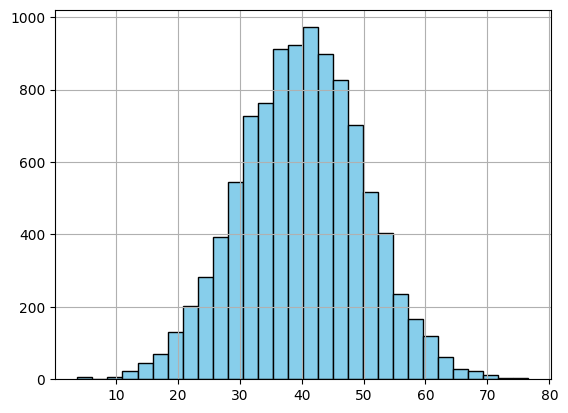

In [35]:

df['Torque_[Nm]'].hist(bins=30, color= "skyblue", edgecolor="black")

In [ ]:
# normal dist above

In [39]:
df.columns

Index(['UDI', 'Product_ID', 'Type', 'Air_temperature_[K]',
       'Process_temperature_[K]', 'Rotational_speed_[rpm]', 'Torque_[Nm]',
       'Tool_wear_[min]', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

<Axes: ylabel='count'>

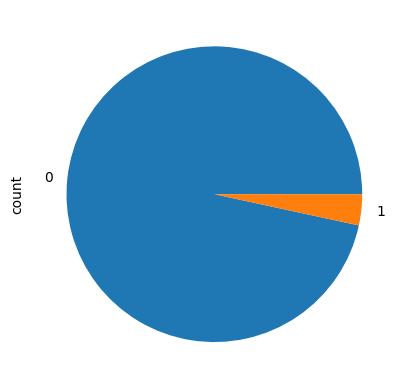

In [43]:
df.Machine_failure.value_counts().plot(kind="pie", color= ['Red', 'Green', 'blue'])

<Axes: ylabel='count'>

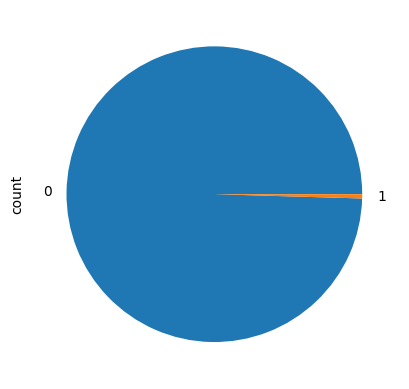

In [47]:
df.TWF.value_counts().plot(kind="pie", color= ['Red', 'Green', 'blue'])

<Axes: ylabel='count'>

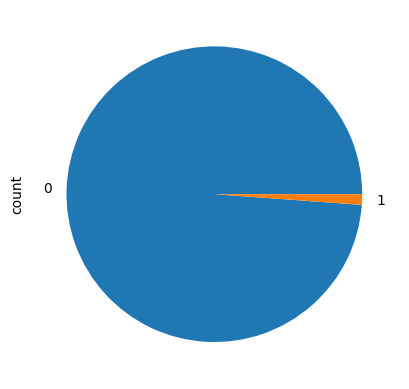

In [48]:
df.HDF.value_counts().plot(kind="pie", color= ['Red', 'Green', 'blue'])

In [49]:
pd.crosstab(df["Type"], df["Machine_failure"])

Machine_failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [ ]:
# type L has more machine failures than type H and type M, so type L is more prone to machine failure

In [ ]:
# now initial eda is done, now clean the dataset and prepare it for model building

In [ ]:
# data set cleaning

In [50]:
df.isnull()

,UDI,Product_ID,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,TWF,HDF,PWF,OSF,RNF
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [51]:
df.isnull().sum()

UDI                        0
Product_ID                 0
Type                       0
Air_temperature_[K]        0
Process_temperature_[K]    0
Rotational_speed_[rpm]     0
Torque_[Nm]                0
Tool_wear_[min]            0
Machine_failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [ ]:
# no null values in the dataset, so no need to handle missing values

In [52]:
df.columns

Index(['UDI', 'Product_ID', 'Type', 'Air_temperature_[K]',
       'Process_temperature_[K]', 'Rotational_speed_[rpm]', 'Torque_[Nm]',
       'Tool_wear_[min]', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

<Axes: >

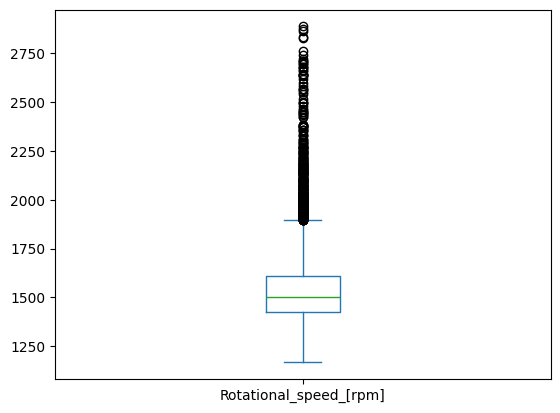

In [53]:
df['Rotational_speed_[rpm]'].plot(kind= "box")

In [ ]:
# outlier present, handle it by removing the outlier values from the dataset 

In [57]:
Q1 = df['Rotational_speed_[rpm]'].quantile(0.25)
Q3 = df['Rotational_speed_[rpm]'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['Rotational_speed_[rpm]'] >= lower_limit) &
    (df['Rotational_speed_[rpm]'] <= upper_limit)
]

In [ ]:
# Q1 = 25th percentile
# Q3 = 75th percentile
#         ↓
# IQR = Q3 - Q1
#         ↓
# Lower = Q1 - 1.5 × IQR
# Upper = Q3 + 1.5 × IQR
#         ↓
# Keep values between Lower and Upper
#         ↓
# Values outside = statistical outliers

<Axes: >

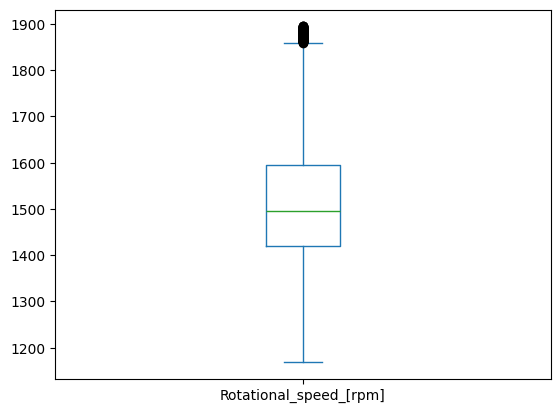

In [58]:
df['Rotational_speed_[rpm]'].plot.box()

In [ ]:
# detect outliers by boxplot and remove using IQR 

<Axes: >

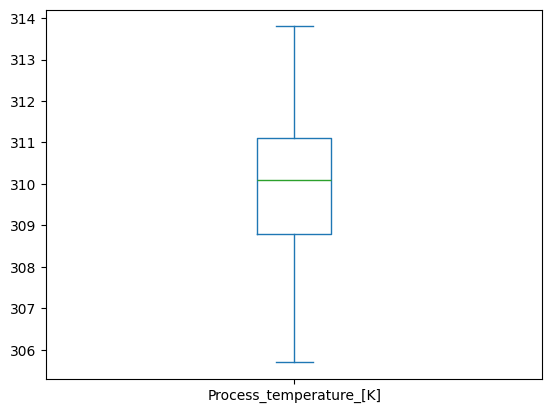

In [59]:
df['Process_temperature_[K]'].plot(kind= "box")

In [ ]:
# no ouliers present here 

In [60]:
df.columns

Index(['UDI', 'Product_ID', 'Type', 'Air_temperature_[K]',
       'Process_temperature_[K]', 'Rotational_speed_[rpm]', 'Torque_[Nm]',
       'Tool_wear_[min]', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

<Axes: >

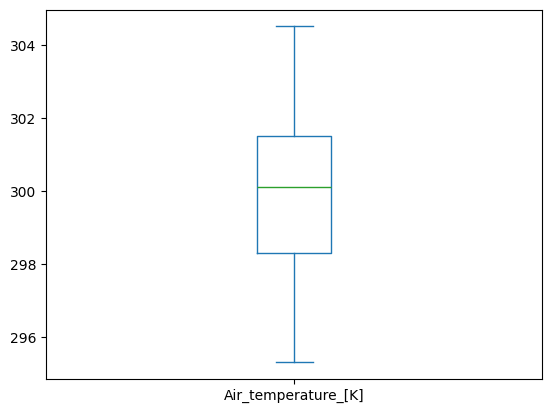

In [61]:
df['Air_temperature_[K]'].plot(kind= "box")

<Axes: >

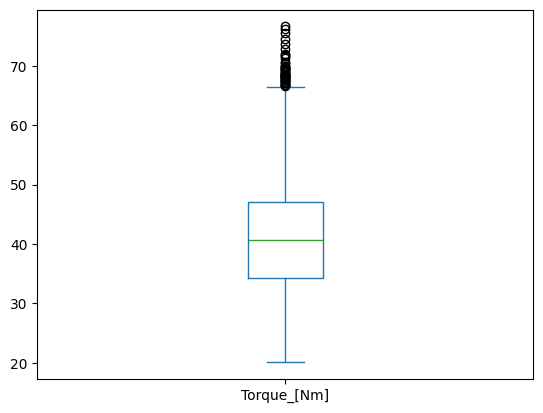

In [62]:
df['Torque_[Nm]'].plot(kind= "box")

In [63]:
Q1 = df['Torque_[Nm]'].quantile(0.25)
Q3 = df['Torque_[Nm]'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['Torque_[Nm]'] >= lower_limit) &
    (df['Torque_[Nm]'] <= upper_limit)
]

<Axes: >

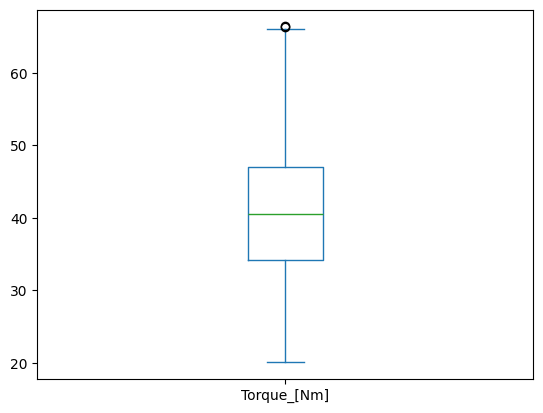

In [64]:
df['Torque_[Nm]'].plot(kind= "box")

In [ ]:
# remove outliers of each column in same way

In [ ]:
# data understanding , initail eda , cleaning data done now
# second eda starts : use many types of charts and plot the graphs also use groupby, sort , rank functions also

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [8]:
df.groupby('Type')['Machine failure'].sum()

Type
H     21
L    235
M     83
Name: Machine failure, dtype: int64

In [12]:
df.groupby('Type').agg(
    {
        'Rotational speed [rpm]': 'mean'
    }
)

,Rotational speed [rpm]
Type,
H,1538.147557
L,1539.469167
M,1537.598932


In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# using box plot, bar chart , pie chart , histogram , etc do data visualization that is second eda 